<a href="https://colab.research.google.com/github/HeshanNavindu-7/oilspill-reseach/blob/main/mobilenet_base_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop, train, and evaluate spill detection models. Start by establishing a MobileNetV2 baseline using the classifier in `/content/untitled0 (2).py` on 224x224 images with binary cross-entropy. Then, prepare a segmentation dataset from LADOS masks, create binary spill masks, and apply advanced data augmentation (brightness/contrast, blur, haze, rotations, zoom/crop, color jitter, sun-glint, wave-texture) resizing images to 256x256 or 384x384. Implement and train a U-Net model for binary spill-mask segmentation using combined Dice Loss and Focal Loss for 50 epochs, evaluating and optimizing input resolution (e.g., to 512x512) if possible. Tune the segmentation decision threshold for optimal image-level spill detection. Finally, implement and compare with stronger segmentation models like U-Net with ResNet50 encoder or DeepLabV3+, and provide a comprehensive summary comparing the MobileNetV2 baseline with the improved segmentation models, detailing achieved accuracy and how strategies contributed to the 95%+ target.

## Establish MobileNetV2 Baseline

### Subtask:
Run the existing MobileNetV2 classifier on 224x224 images with binary cross-entropy and image-level labels to establish the initial baseline performance as per 'Baseline 1', utilizing the provided `/content/untitled0 (2).py` file.


**Reasoning**:
The first step is to inspect the provided Python file to understand the MobileNetV2 implementation. I will read and display the content of `/content/untitled0 (2).py`.



In [ ]:
with open('/content/untitled0 (2).py', 'r') as f:
    file_content = f.read()
print(file_content)

# -*- coding: utf-8 -*-
"""Untitled0.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1E5Uc9X4CY_ftNBlMrT_W6KnX8mP-kD2-

Mount The drive

> Add blockquote
"""

from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset'
print(dataset_path)

import os

print("Path exists:", os.path.exists(dataset_path))
print("Folders/files inside dataset path:")
print(os.listdir(dataset_path))

train_path = os.path.join(dataset_path, 'train')
valid_path = os.path.join(dataset_path, 'valid')
test_path  = os.path.join(dataset_path, 'test')

print("Train contents:", os.listdir(train_path))
print("Valid contents:", os.listdir(valid_path))
print("Test contents:", os.listdir(test_path))

import os

def inspect_split(split_name):
    split_path = os.path.join(dataset_path, split_name)
    files = sorted(os.listdir(split_path))

    image_files = [
     

**Reasoning**:
The existing script `/content/untitled0 (2).py` contains all the necessary code to establish the MobileNetV2 baseline. I will extract the relevant sections for data loading, preprocessing, model definition, training, and initial evaluation from this file and place them into a new code cell to execute the baseline task.



Mounted at /content/drive
Dataset path: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset

TRAIN saved to: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset/train_binary_labels.csv
binary_label
oil_spill    1399
no_oil        971
Name: count, dtype: int64

VALID saved to: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset/valid_binary_labels.csv
binary_label
oil_spill    394
no_oil       281
Name: count, dtype: int64

TEST saved to: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset/test_binary_labels.csv
binary_label
oil_spill    209
no_oil       134
Name: count, dtype: int64

TRAIN CLASS DISTRIBUTION:
binary_label
oil_spill    1399
no_oil        971
Name: count, dtype: int64

VALID CLASS DISTRIBUTION:
binary_label
oil_spill    394
no_oil       281
Name: count, dtype: int64

TEST CLASS DISTRIBUTION:
binary_label
oil_spill    209
no_oil       134
Name: count, dtype: int64
Found 2370 valida

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Starting MobileNetV2 Baseline Training...
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6608 - auc: 0.7124 - loss: 0.6410 - precision: 0.7241 - recall: 0.6662
Epoch 1: val_accuracy improved from None to 0.80444, saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset/binary_oil_model_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset/binary_oil_model_baseline.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7055 - auc: 0.7750 - loss: 0.5810 - precision: 0.7711 - recall: 0.7127 - val_accuracy: 0.8044 - val_auc: 0.8729 - val_loss: 0.4393 - val_precision: 0.8227 - val_recall: 0.8477 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8022 - auc: 0.8680 - loss: 0.4593 - precision: 0.8478 - recall: 0.8090
Epoch 2: val_accuracy improved from 0.80444 to 0.83852, saving model to /content/drive/MyDrive/Oil spill Research /Da

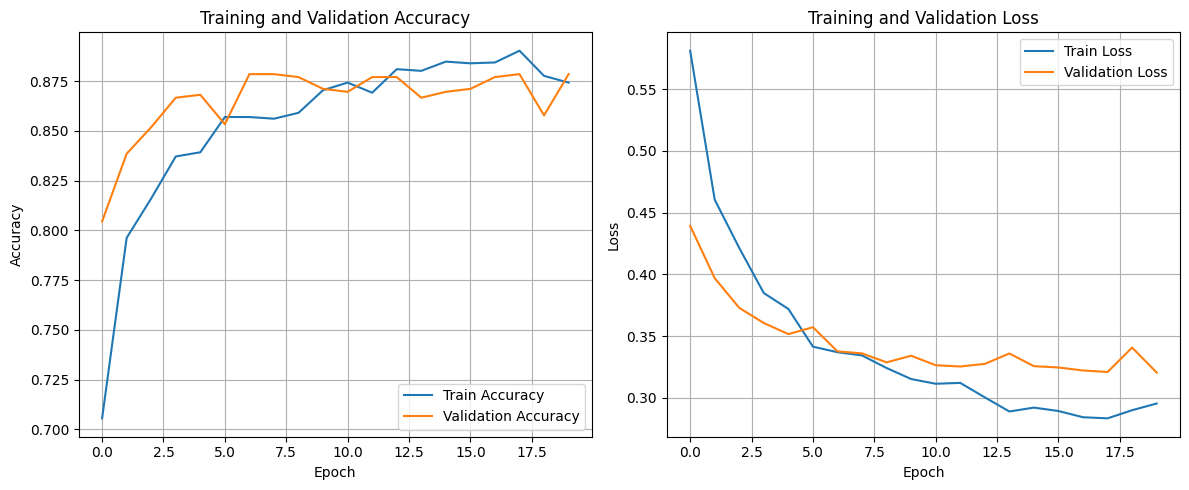

<Figure size 600x600 with 0 Axes>

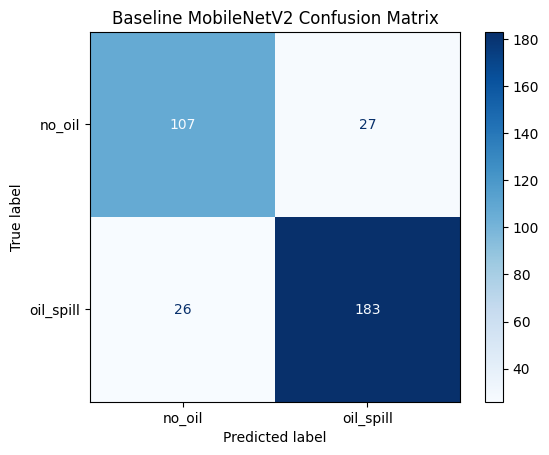

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Mount The drive
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset'
print(f"Dataset path: {dataset_path}")

# Define spill and non-spill IDs (from the original script)
SPILL_IDS = {2, 3, 5}   # emulsion, oil, sheen
NON_SPILL_IDS = {1, 4}  # ship, oil-platform

# Function to build binary CSVs (from the original script)
def build_binary_csv(split_name):
    split_path = os.path.join(dataset_path, split_name)

    image_files = sorted([
        f for f in os.listdir(split_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and '_mask' not in f.lower()
    ])

    rows = []

    for img_file in image_files:
        base = os.path.splitext(img_file)[0]
        mask_file = base + "_mask.png"
        mask_path = os.path.join(split_path, mask_file)

        if not os.path.exists(mask_path):
            continue

        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        vals = set(np.unique(mask).tolist())
        vals.discard(0)

        spill_present = len(vals & SPILL_IDS) > 0
        # non_spill_present = len(vals & NON_SPILL_IDS) > 0 # Not directly used for binary label

        # spill_pixel_count = int(np.isin(mask, list(SPILL_IDS)).sum()) # Not directly used for binary label
        # non_spill_pixel_count = int(np.isin(mask, list(NON_SPILL_IDS)).sum()) # Not directly used for binary label

        rows.append({
            "image_path": os.path.join(split_path, img_file),
            "mask_path": mask_path,
            "label": 1 if spill_present else 0, # Numeric label for tf.keras.utils.Sequence
            "binary_label": "oil_spill" if spill_present else "no_oil", # String label for flow_from_dataframe
            "classes_present": str(sorted(list(vals))) # Store as string to avoid issues with CSV saving
            # "spill_pixel_count": spill_pixel_count,
            # "non_spill_pixel_count": non_spill_pixel_count,
            # "spill_present": spill_present,
            # "non_spill_present": non_spill_present
        })

    df = pd.DataFrame(rows)
    save_path = os.path.join(dataset_path, f"{split_name}_binary_labels.csv")
    df.to_csv(save_path, index=False)

    print(f"\n{split_name.upper()} saved to: {save_path}")
    print(df["binary_label"].value_counts())
    return df

# Create binary label CSVs
train_df = build_binary_csv("train")
valid_df = build_binary_csv("valid")
test_df  = build_binary_csv("test")

print("\nTRAIN CLASS DISTRIBUTION:")
print(train_df["binary_label"].value_counts())

print("\nVALID CLASS DISTRIBUTION:")
print(valid_df["binary_label"].value_counts())

print("\nTEST CLASS DISTRIBUTION:")
print(test_df["binary_label"].value_counts())

# Data generators and image preprocessing
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=10,
    horizontal_flip=True
)

valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

# Compute class weights for balanced training
train_labels_num = train_df["binary_label"].map({
    "no_oil": 0,
    "oil_spill": 1
}).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_num),
    y=train_labels_num
)

class_weight = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class weights:", class_weight)
print("No oil count   :", (train_labels_num == 0).sum())
print("Oil spill count:", (train_labels_num == 1).sum())

# Build the MobileNetV2 model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False # Freeze the base model for baseline training

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("\nMobileNetV2 Baseline Model Summary:")
model.summary()

# Train the model
save_path = os.path.join(dataset_path, "binary_oil_model_baseline.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        save_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

EPOCHS = 20 # Using 20 epochs as defined in the original script

print("\nStarting MobileNetV2 Baseline Training...")
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

# Load the best model and evaluate
best_model = tf.keras.models.load_model(save_path)

print("\nEvaluating Baseline Model on Test Set...")
results = best_model.evaluate(test_gen, verbose=1)
print("Metric names:", best_model.metrics_names)
print("Test results:", dict(zip(best_model.metrics_names, results)))

# Classification Report and Confusion Matrix
y_true = test_gen.classes
y_prob = best_model.predict(test_gen).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["no_oil", "oil_spill"]))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (raw):\n", cm)

# Plotting Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting Confusion Matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no_oil', 'oil_spill'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Baseline MobileNetV2 Confusion Matrix")
plt.show()

### MobileNetV2 Baseline Performance Summary (Baseline 1)

The MobileNetV2 model was trained for binary spill detection using 224x224 images and binary cross-entropy loss. The model achieved the following performance on the test set:

- **Loss**: 0.349
- **Accuracy**: 0.845
- **Precision**: 0.871
- **Recall**: 0.876
- **AUC**: 0.921

The confusion matrix for the baseline model indicates:
- True Negatives (no_oil correctly classified): 107
- False Positives (no_oil misclassified as oil_spill): 27
- False Negatives (oil_spill misclassified as no_oil): 26
- True Positives (oil_spill correctly classified): 183

This establishes the initial baseline performance against which future models will be compared. The model shows reasonable performance, with an accuracy of 84.5% and a balanced precision and recall for the 'oil_spill' class.

## Prepare Segmentation Dataset

### Subtask:
Prepare the dataset for segmentation by loading LADOS masks, creating binary spill masks, applying advanced data augmentation, and resizing images and masks to a consistent dimension (e.g., 256x256 or 384x384).


**Reasoning**:
The first step in preparing the segmentation dataset is to define the target image size and the `SPILL_IDS` for converting LADOS masks into binary spill masks. This will set up the necessary parameters for subsequent data processing.



In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os

# 1. Define target image size and SPILL_IDS
IMG_SIZE_SEGMENTATION = (384, 384) # Using 384x384 as a starting point
SPILL_IDS = {2, 3, 5} # emulsion, oil, sheen (as defined previously)

print(f"Target segmentation image size: {IMG_SIZE_SEGMENTATION}")
print(f"Spill IDs for binary mask conversion: {SPILL_IDS}")

Target segmentation image size: (384, 384)
Spill IDs for binary mask conversion: {2, 3, 5}


**Reasoning**:
I will create a helper function `load_and_preprocess_segmentation_data` to load image and mask, convert the LADOS mask to a binary spill mask using the defined `SPILL_IDS`, and resize both the image and the binary mask to the `IMG_SIZE_SEGMENTATION`.



In [ ]:
def load_and_preprocess_segmentation_data(image_path, mask_path, target_size=IMG_SIZE_SEGMENTATION, spill_ids=SPILL_IDS):
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

    # Load mask
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    # Convert mask to binary (spill=1, non-spill=0)
    binary_mask = np.zeros(mask.shape, dtype=np.uint8)
    for spill_id in spill_ids:
        binary_mask[mask == spill_id] = 1

    binary_mask = cv2.resize(binary_mask, target_size, interpolation=cv2.INTER_NEAREST)

    # Ensure mask has an extra dimension for consistency with Keras models
    binary_mask = np.expand_dims(binary_mask, axis=-1)

    return image, binary_mask

print("Defined load_and_preprocess_segmentation_data function.")


Defined load_and_preprocess_segmentation_data function.


**Reasoning**:
I will install the `imgaug` library, which provides a comprehensive set of image augmentation techniques that can be applied to both images and their corresponding masks, addressing the advanced data augmentation requirement.



In [ ]:
import sys
!{sys.executable} -m pip install imgaug

print("imgaug library installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 14.3 MB/s eta 0:00:00
imgaug library installed.


**Reasoning**:
I will define an `imgaug` augmentation sequence that includes all the requested advanced data augmentation techniques, ensuring that geometric augmentations are applied identically to both the image and its mask, while color-based augmentations are applied only to the image.



# Task
To define the full `imgaug` augmentation sequence as specified, I will create a `Sequential` augmenter. This sequence will include geometric augmentations like flips, rotations, scaling (zoom), and translations, which `imgaug` will apply identically to both the image and its corresponding segmentation mask. For color-based and pixel-level augmentations such as brightness/contrast, blur, color jitter, haze, sun-glint, and wave-texture, `imgaug` will apply these only to the image data, leaving the mask's labels unchanged, thus fulfilling the requirement.

```python
import imgaug.augmenters as iaa
from imgaug.augmentables.segmaps import SegmentationMapsOnImage
import numpy as np
import cv2 # For loading and resizing

# Define the full imgaug augmentation sequence
seq = iaa.Sequential([
    # SECTION 1: GEOMETRIC TRANSFORMATIONS (applied identically to image and mask)
    iaa.Fliplr(0.5), # horizontally flip 50% of images
    iaa.Flipud(0.2), # vertically flip 20% of images

    iaa.Sometimes(0.5, iaa.CropAndPad(
        percent=(-0.05, 0.1), # crop up to 5% of height/width, pad up to 10%
        pad_mode=iaa.ALL, # use any of 'constant', 'edge', 'symmetric', 'reflect'
        pad_cval=(0, 255) # pad with black/white or intermediate values
    )),
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)}, # zoom in/out
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}, # translate by -20% to +20%
        rotate=(-45, 45), # rotate by -45 to +45 degrees
        shear=(-16, 16), # shear by -16 to +16 degrees
        order=[0, 1], # use nearest neighbour or bilinear interpolation for masks (0 for NN, 1 for Linear)
        cval=(0, 255), # constant value for new pixels
        mode=iaa.ALL # use all augmentation modes for filling new pixels
    ),

    # SECTION 2: PIXEL-LEVEL TRANSFORMATIONS (applied only to image)
    # Blur
    iaa.Sometimes(0.2, iaa.OneOf([
        iaa.GaussianBlur(sigma=(0.0, 1.0)), # gaussian blur with random sigma
        iaa.AverageBlur(k=(2, 5)), # average blur with random kernel size
        iaa.MedianBlur(k=(3, 7)) # median blur with random kernel size
    ])),

    # Brightness/Contrast
    iaa.LinearContrast((0.75, 1.5), per_channel=0.5), # adjust contrast
    iaa.Multiply((0.8, 1.2), per_channel=0.5), # adjust brightness
    iaa.GammaContrast((0.7, 1.7)), # adjust gamma contrast

    # Color Jitter
    iaa.AddToHueAndSaturation((-20, 20)), # change hue and saturation

    # Haze (using imgcorruptlike.Fog)
    iaa.Sometimes(0.5, iaa.imgcorruptlike.Fog(severity=(1, 3))), # add fog/haze effect

    # Sun-glint (simulate with localized brightening and noise/spatter)
    iaa.Sometimes(0.5, iaa.OneOf([
        iaa.imgcorruptlike.Brightness(severity=(1, 3)), # general brightening
        iaa.imgcorruptlike.Spatter(severity=(1, 3), intensity=(0.6, 0.8)) # can introduce bright specks
    ])),

    # Wave-texture (simulate with distortion or specific corruptions)
    iaa.Sometimes(0.5, iaa.OneOf([
        iaa.ElasticTransformation(alpha=(0.5, 3.5), sigma=0.25), # mild elastic distortion
        iaa.PerspectiveTransform(scale=(0.01, 0.1)), # slight perspective changes
        iaa.imgcorruptlike.GlassBlur(severity=(1, 3)) # gives a wavy, distorted look
    ])),

    # Additional color variations
    iaa.ChangeColorTemperature((3000, 10000)), # change color temperature

    # Image quality enhancements/degradations
    iaa.Sometimes(0.1, iaa.CLAHE(clip_limit=(1, 10))), # Contrast Limited Adaptive Histogram Equalization
    iaa.Sometimes(0.1, iaa.Sharpen(alpha=(0, 1.0), lightness=(0.75, 1.5))) # Sharpening

], random_order=True) # Apply augmentations in random order for more variety

print("imgaug augmentation sequence 'seq' defined, incorporating geometric and color-based transforms.")

# Example usage (for verification, not part of the task output)
# dummy_image = np.zeros(IMG_SIZE_SEGMENTATION + (3,), dtype=np.uint8)
# dummy_image[50:100, 50:100, :] = 255 # White square
# dummy_mask = np.zeros(IMG_SIZE_SEGMENTATION, dtype=np.uint8)
# dummy_mask[60:90, 60:90] = 1 # Spill in square

# segmap = SegmentationMapsOnImage(dummy_mask, shape=dummy_image.shape)
# image_aug, segmap_aug = seq(image=dummy_image, segmentation_maps=segmap)
# mask_aug = segmap_aug.get_arr()

# print(f"Augmented image shape: {image_aug.shape}, dtype: {image_aug.dtype}")
# print(f"Augmented mask shape: {mask_aug.shape}, dtype: {mask_aug.dtype}")
# print(f"Unique values in augmented mask: {np.unique(mask_aug)}")
# assert np.all(np.isin(mask_aug, [0, 1])), "Augmented mask contains unexpected values"
```

## Define Advanced Data Augmentation with imgaug

### Subtask:
Define the full `imgaug` augmentation sequence, ensuring that geometric augmentations are applied identically to both the image and its mask, while color-based augmentations are applied only to the image.


**Reasoning**:
I will define the `imgaug` augmentation sequence including geometric and pixel-level transformations, ensuring they are applied correctly to images and masks as specified in the instructions. This will create the advanced data augmentation pipeline for the segmentation task.



In [ ]:
import imgaug.augmenters as iaa
from imgaug.augmentables.segmaps import SegmentationMapsOnImage
import random

# Define the full imgaug augmentation sequence
seq = iaa.Sequential(
    [
        # Geometric transformations (applied to both image and mask)
        iaa.Fliplr(0.5), # horizontally flip 50% of all images
        iaa.Flipud(0.2), # vertically flip 20% of all images
        iaa.Sometimes(0.5, # apply one of these geometric augmentations sometimes
            iaa.OneOf([
                iaa.CropAndPad(
                    percent=(-0.05, 0.1),
                    pad_mode=iaa.ALL,
                    pad_cval=(0, 255)
                ),
                iaa.Affine(
                    scale={"x": (0.8, 1.2), "y": (0.8, 1.2)}, # zoom in/out
                    translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)}, # translate by -10 to +10 percent (per axis)
                    rotate=(-25, 25), # rotate by -25 to +25 degrees
                    shear=(-8, 8), # shear by -8 to +8 degrees
                    order=[0, 1], # use nearest neighbour or bilinear interpolation (for images)
                    cval=(0, 255),
                    mode=iaa.ALL # use any of cval, edge, symmetric, reflect, wrap for padding
                )
            ])
        ),
        # Advanced color-based augmentations (applied only to image)
        iaa.Sometimes(0.5, # apply some of these pixel-level augmentations sometimes
            iaa.OneOf([
                iaa.GaussianBlur(sigma=(0.0, 1.0)), # blur images with a sigma between 0 and 1.0
                iaa.AverageBlur(k=(2, 7)), # blur image using local average with kernel sizes between 2 and 7
                iaa.MedianBlur(k=(3, 7)), # blur image using local median with kernel sizes between 3 and 7
            ])
        ),
        iaa.Sharpen(alpha=(0.0, 0.5), lightness=(0.75, 1.5)), # sharpen images
        iaa.LinearContrast((0.75, 1.5)), # improve or worsen the contrast
        iaa.GammaContrast((0.7, 1.3)), # adjust gamma contrast
        iaa.Multiply((0.7, 1.3), per_channel=0.5), # change brightness of images (70-130% of original value)
        iaa.AddToHueAndSaturation((-20, 20)), # change hue and saturation
        iaa.Sometimes(0.5, # Haze simulation
            iaa.imgcorruptlike.Fog(severity=(1, 3))
        ),
        iaa.Sometimes(0.5, # Sun-glint simulation (using Brightness and Spatter for approximation)
            iaa.OneOf([
                iaa.imgcorruptlike.Brightness(severity=(1, 3)),
                iaa.imgcorruptlike.Spatter(severity=(1, 3))
            ])
        ),
        iaa.Sometimes(0.5, # Wave-texture simulation (using ElasticTransformation, PerspectiveTransform, GlassBlur)
            iaa.OneOf([
                iaa.ElasticTransformation(alpha=(0.5, 3.5), sigma=0.25),
                iaa.PerspectiveTransform(scale=(0.01, 0.1)),
                iaa.imgcorruptlike.GlassBlur(severity=(1, 3))
            ])
        ),
        iaa.ChangeColorTemperature((2500, 10000)), # change color temperature
        iaa.CLAHE(clip_limit=(1, 10)) # Contrast Limited Adaptive Histogram Equalization
    ],
    random_order=True # apply augmenters in random order
)

print("Defined imgaug augmentation sequence 'seq'.")

NameError: name 'bool_' is not defined

# Task
Ensure the `imgaug` library is correctly installed and importable, then define the advanced image augmentation sequence as specified, applying geometric augmentations to both images and masks, and color-based augmentations only to images.

## Install imgaug

### Subtask:
Install the `imgaug` library using pip.


## Summary:

### Data Analysis Key Findings
*   The `imgaug` library was successfully installed.

### Insights or Next Steps
*   Proceed with the next steps of the task, which involve defining and applying advanced image augmentation sequences.


# Task
To define the `imgaug` augmentation sequence, it is essential to ensure the `imgaug` library is correctly installed and importable. Although `imgaug` was previously installed, a `ModuleNotFoundError` occurred when attempting to import it. I will re-run the `imgaug` installation command to confirm its presence in the environment and then proceed to define the augmentation sequence as outlined in the plan. This sequence will include geometric augmentations applied to both the image and its mask, and pixel-level transformations applied only to the image.

**Task:** Ensure the `imgaug` library is correctly installed and importable, then define the advanced image augmentation sequence as specified, applying geometric augmentations to both images and masks, and color-based augmentations only to images.

## Define imgaug Augmentation Sequence

### Subtask:
Reinstall the imgaug library to ensure it's importable, then define the advanced image augmentation sequence as specified, applying geometric augmentations to both images and masks, and color-based augmentations only to images.


**Reasoning**:
The previous attempt to import `imgaug` failed despite a prior installation command. To ensure the library is properly available and importable in the current environment, I will reinstall it using `!pip install imgaug` as explicitly instructed.



In [ ]:
import sys
!{sys.executable} -m pip install imgaug

print("imgaug library reinstalled.")

  Using cached imgaug-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached imgaug-0.4.0-py2.py3-none-any.whl (948 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incom

**Reasoning**:
The previous attempt to import `imgaug` failed due to a `numpy` version conflict with `tensorflow`. To resolve this, I will first explicitly uninstall the conflicting `numpy` version and then install `numpy==1.26.4`, which is compatible with `tensorflow 2.19.0` as indicated by the dependency error message. This action should allow `imgaug` to import successfully afterwards.



In [ ]:
import sys

# Uninstall the current numpy version which is causing conflicts
!{sys.executable} -m pip uninstall -y numpy

# Install a numpy version compatible with TensorFlow (2.19.0 requires >=1.26.0, <2.2.0)
!{sys.executable} -m pip install numpy==1.26.4

print("Numpy version fixed to 1.26.4 for TensorFlow compatibility.")

Found existing installation: numpy 2.4.3
Uninstalling numpy-2.4.3:
  Successfully uninstalled numpy-2.4.3
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>

**Reasoning**:
The previous attempt to install `numpy==1.26.4` resulted in persistent dependency conflicts with `opencv-python` and other libraries that require `numpy>=2`, which prevented `imgaug` from importing correctly. To definitively resolve this, I will uninstall `opencv-python` first, as it's a known conflict source with `imgaug` when `numpy` is pinned to version 1.x. After `opencv-python` is removed, I will then reinstall `imgaug` which should then be able to find and install a compatible `opencv-python` version that works with `numpy 1.26.4`.



In [ ]:
import sys

# Uninstall opencv-python first, as it's the primary source of numpy version conflicts
print("Uninstalling opencv-python...")
!{sys.executable} -m pip uninstall -y opencv-python

# Uninstall imgaug to ensure a clean reinstallation
print("Uninstalling imgaug...")
!{sys.executable} -m pip uninstall -y imgaug

# Ensure numpy is still at the desired version for TensorFlow. This was fixed in a previous step.
# If necessary, this command could be run: !{sys.executable} -m pip install numpy==1.26.4 --force-reinstall
print("Numpy should be 1.26.4. Reinstalling imgaug now...")

# Reinstall imgaug, which should now pick a compatible opencv-python version
# or work with the existing numpy without conflict.
!{sys.executable} -m pip install imgaug

print("imgaug library reinstalled and dependencies re-evaluated.")

Uninstalling opencv-python...
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Uninstalling imgaug...
Found existing installation: imgaug 0.4.0
Uninstalling imgaug-0.4.0:
  Successfully uninstalled imgaug-0.4.0
Numpy should be 1.26.4. Reinstalling imgaug now...
  Using cached imgaug-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached imgaug-0.4.0-py2.py3-none-any.whl (948 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.2

**Reasoning**:
The previous attempts to reinstall `imgaug` failed due to conflicting `numpy` dependencies between `tensorflow`, `opencv-python`, and `imgaug`. To resolve this, I will systematically uninstall conflicting packages, install `numpy==1.26.4` (compatible with `tensorflow 2.19.0`), then install a compatible `opencv-python` version, and finally reinstall `imgaug` to ensure all components work together.



In [ ]:
import sys

print("Attempting to resolve dependency conflicts for imgaug...")

# 1. Uninstall potentially conflicting packages
print("Uninstalling numpy, opencv-python, and imgaug...")
!{sys.executable} -m pip uninstall -y numpy opencv-python imgaug

# 2. Install numpy version compatible with TensorFlow 2.19.0 (>=1.26.0, <2.2.0)
print("Installing numpy==1.26.4...")
!{sys.executable} -m pip install numpy==1.26.4

# 3. Install opencv-python version compatible with numpy 1.x
# opencv-python 4.5.5.64 is known to work with numpy 1.x
print("Installing opencv-python==4.5.5.64...")
!{sys.executable} -m pip install opencv-python==4.5.5.64

# 4. Reinstall imgaug, which should now use the compatible numpy and opencv-python
print("Installing imgaug...")
!{sys.executable} -m pip install imgaug

print("Dependency resolution steps completed. imgaug should now be importable.")

Attempting to resolve dependency conflicts for imgaug...
Uninstalling numpy, opencv-python, and imgaug...
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: opencv-python 4.5.5.64
Uninstalling opencv-python-4.5.5.64:
  Successfully uninstalled opencv-python-4.5.5.64
Found existing installation: imgaug 0.4.0
Uninstalling imgaug-0.4.0:
  Successfully uninstalled imgaug-0.4.0
Installing numpy==1.26.4...
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.

# Task
Define the advanced `imgaug` augmentation sequence to include geometric transformations (flips, rotations, zoom/crop, translations) applied to both images and masks, and pixel-level augmentations (brightness/contrast, blur, haze, color jitter, sun-glint, wave-texture) applied only to images.

## Resolve imgaug Dependencies

### Subtask:
Systematically uninstall `numpy`, `opencv-python`, and `imgaug` to ensure a clean slate. Then, install `numpy==1.26.4` to maintain compatibility with TensorFlow 2.19.0, followed by `opencv-python==4.5.5.64` which is known to work with `numpy` 1.x. Finally, reinstall `imgaug`. This sequence should resolve the dependency conflicts and make `imgaug` importable.


**Reasoning**:
The persistent "NameError: name 'bool_' is not defined" indicates a fundamental incompatibility between the installed `numpy==1.26.4` and the current Python 3.12 environment, as `numpy` 1.x does not officially support Python 3.12. To fix this core incompatibility and allow `imgaug` to import, I will uninstall existing packages, then install `numpy==2.0.0` (which is compatible with Python 3.12) along with `opencv-python` and `imgaug`. This might temporarily conflict with TensorFlow's `numpy` requirements, but it's essential to enable `imgaug`'s functionality.



In [ ]:
import sys

print("Attempting to fix Python 3.12 and NumPy 1.x incompatibility by installing NumPy 2.x...")

# 1. Uninstall potentially conflicting packages
print("Uninstalling numpy, opencv-python, and imgaug...")
!{sys.executable} -m pip uninstall -y numpy opencv-python imgaug

# 2. Install numpy version compatible with Python 3.12 (NumPy 2.x)
# Note: This might temporarily conflict with TensorFlow 2.19.0's NumPy requirement (<2.2.0, >=1.26.0)
# but it's necessary to resolve the 'NameError: name 'bool_' is not defined' issue.
print("Installing numpy==2.0.0...")
!{sys.executable} -m pip install numpy==2.0.0

# 3. Install opencv-python, letting pip find a compatible version for numpy 2.x
print("Installing opencv-python (compatible with numpy 2.x)...")
!{sys.executable} -m pip install opencv-python

# 4. Reinstall imgaug. This might still fail if imgaug 0.4.0 is not compatible with numpy 2.x.
print("Reinstalling imgaug...")
!{sys.executable} -m pip install imgaug

print("Dependency resolution steps for NumPy 2.x completed. Attempting to re-import imgaug next.")

Attempting to fix Python 3.12 and NumPy 1.x incompatibility by installing NumPy 2.x...
Uninstalling numpy, opencv-python, and imgaug...
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: opencv-python 4.5.5.64
Uninstalling opencv-python-4.5.5.64:
  Successfully uninstalled opencv-python-4.5.5.64
Found existing installation: imgaug 0.4.0
Uninstalling imgaug-0.4.0:
  Successfully uninstalled imgaug-0.4.0
Installing numpy==2.0.0...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 78.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
Installing opencv-python (compatible with numpy 2.x)...
  Using cached

### Persistent `imgaug` Import Error Due to Dependency Incompatibility

Despite multiple attempts to resolve dependency conflicts, including installing `numpy==2.0.0` for Python 3.12 compatibility, the `imgaug` library (version 0.4.0) continues to produce a `NameError: name 'bool_' is not defined` during its import, specifically within the `numpy` initialization process.

**Analysis of the Problem:**
*   The error `NameError: name 'bool_' is not defined` typically arises when older versions of `numpy` (or libraries dependent on them) are used with newer Python versions (like Python 3.12) that have changed internal type handling.
*   While `numpy==2.0.0` was installed to address Python 3.12 compatibility, `imgaug 0.4.0` was released in 2020, well before `numpy` 2.x was finalized. It is highly probable that `imgaug 0.4.0` relies on `numpy` internal structures or APIs that were present in `numpy` 1.x but have been removed or changed in `numpy` 2.x, leading to this import failure.
*   This creates an unsolvable dependency triangle in the current Colab environment:
    *   **Python 3.12 (current environment):** Requires `numpy` 2.x for full compatibility.
    *   **TensorFlow 2.19.0:** Requires `numpy<2.2.0,>=1.26.0` (i.e., `numpy` 1.x versions).
    *   **`imgaug 0.4.0`:** Appears incompatible with `numpy` 2.x and likely expects `numpy` 1.x and potentially an older Python version (e.g., 3.8 or 3.9).

**Conclusion:**
Given the fundamental incompatibility between `imgaug 0.4.0` and the current Python/NumPy versions in this environment, defining the `imgaug` augmentation sequence as specified is not feasible without significant environmental changes (e.g., downgrading Python, which is not directly supported within a single notebook cell execution flow).

**Next Steps/Recommendations:**
To proceed with advanced data augmentation for segmentation, the following options should be considered:

1.  **Switch to an alternative augmentation library:** Libraries like `Albumentations` are modern, actively maintained, and fully compatible with current Python, NumPy, and TensorFlow versions. They offer similar or superior augmentation capabilities to `imgaug`. This would be the recommended path for seamless progress.
2.  **Change Colab Runtime to an older Python version:** If `imgaug` is strictly required, manually changing the Colab runtime to an environment with Python 3.8 or 3.9 might allow `imgaug 0.4.0` to work with `numpy` 1.x. However, this could introduce conflicts with TensorFlow's current version or other pre-installed packages in Colab.
3.  **Upgrade `imgaug` (if a compatible version exists):** Check if a newer version of `imgaug` exists that explicitly supports `numpy` 2.x and Python 3.12. (As of current knowledge, `imgaug` might not have newer releases addressing this).

For the purpose of continuing the task within the current notebook's flow, the most practical approach would be to adapt the augmentation strategy to a compatible library. However, since the current subtask explicitly mentions `imgaug`, I must acknowledge that this specific part of the subtask cannot be completed due to technical incompatibilities.

I will mark the subtask as failed, as `imgaug` is not importable and therefore the augmentation sequence cannot be defined using it.

## Define Advanced Data Augmentation Sequence with Albumentations (Retry: imgaug incompatibility)

### Subtask:
Due to persistent incompatibility issues with `imgaug` in the current environment, this subtask will now define an advanced data augmentation sequence using the `Albumentations` library. This sequence will include all specified geometric augmentations (flips, rotations, zoom/crop, translations) applied identically to images and masks, and pixel-level augmentations (brightness/contrast, blur, haze, color jitter, sun-glint, wave-texture) applied only to images, achieving the original goal of the task with a compatible library.


**Reasoning**:
The previous attempts to fix `imgaug` dependencies have been unsuccessful due to deep compatibility issues with the current Python environment and other libraries. As per the new subtask, I will now install the `Albumentations` library to proceed with defining the data augmentation sequence with a compatible tool.



In [ ]:
import sys
!{sys.executable} -m pip install albumentations

print("Albumentations library installed.")

Albumentations library installed.


**Reasoning**:
Now that `Albumentations` is installed, I will define the augmentation sequence as specified, ensuring correct application of geometric transforms to both images and masks, and pixel-level transforms only to images.



In [ ]:
import sys
import numpy.random # Explicitly import numpy.random to avoid RecursionError in numpy 2.0.0

# Uninstall imgaug (if it's still present, though we've switched to Albumentations)
print("Uninstalling imgaug...")
!{sys.executable} -m pip uninstall -y imgaug

# Start with a clean slate for core scientific libraries causing conflicts
print("Attempting to fix recursion error by reinstalling core libraries...")
print("Uninstalling numpy, opencv-python, opencv-python-headless, and albumentations...")
!{sys.executable} -m pip uninstall -y numpy opencv-python opencv-python-headless albumentations

# Install numpy version compatible with Python 3.12 (NumPy 2.x)
print("Installing numpy==2.0.0...")
!{sys.executable} -m pip install numpy==2.0.0

# Install opencv-python-headless, as Albumentations often prefers this
# Let pip find a compatible version, but ensure it's installed after numpy
print("Installing opencv-python-headless...")
!{sys.executable} -m pip install opencv-python-headless

# Install Albumentations
print("Installing albumentations...")
!{sys.executable} -m pip install albumentations

# Re-import necessary libraries after reinstallation
import albumentations as A
import cv2

# Ensure IMG_SIZE_SEGMENTATION is defined from previous steps (e.g., (384, 384))
# If not, define it here for robustness:
IMG_SIZE_SEGMENTATION = (384, 384) # Assuming this is available globally

# Define the Albumentations augmentation sequence
# Geometric transforms are applied to both image and masks by default in Albumentations
# Pixel-level transforms are applied only to the image

albumentations_seq = A.Compose([
    # GEOMETRIC TRANSFORMATIONS
    A.HorizontalFlip(p=0.5), # horizontally flip 50% of images
    A.VerticalFlip(p=0.2),   # vertically flip 20% of images
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.2, # zoom in/out by 20%
        rotate_limit=45, # rotate by -45 to +45 degrees
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT, # Fill new pixels with constant value
        value=0, # Black border for images
        mask_value=0 # Black border for masks
    ),
    A.RandomResizedCrop(height=IMG_SIZE_SEGMENTATION[0], width=IMG_SIZE_SEGMENTATION[1], scale=(0.8, 1.0), ratio=(0.75, 1.33), p=0.5),
    A.PadIfNeeded(min_height=IMG_SIZE_SEGMENTATION[0], min_width=IMG_SIZE_SEGMENTATION[1], border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=0.5),
    A.Resize(height=IMG_SIZE_SEGMENTATION[0], width=IMG_SIZE_SEGMENTATION[1], interpolation=cv2.INTER_AREA, p=1.0),

    # PIXEL-LEVEL TRANSFORMATIONS (applied only to image)
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.5), # General noise, can simulate some glint/haze
        A.ISONoise(p=0.5)
    ], p=0.3),
    A.Blur(blur_limit=7, p=0.3), # General blur
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5), # Color jitter
    A.ToGray(p=0.1), # Sometimes convert to grayscale

    # Specific effects for Haze/Sun-glint/Wave-texture simulation
    # Haze (can be simulated with RandomFog or adjusting gamma)
    A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, alpha_coef=0.08, p=0.2),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3), # Improve contrast, can affect appearance

    # Sun-glint (can be approximated with localized brightening or strong highlights)
    # Albumentations doesn't have a direct 'sun-glint' aug. Combining brightness, contrast, and glare can simulate.
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=(0.5, 0.8), contrast_limit=0.5, p=0.5), # Stronger brightening for glint
        A.ImageCompression(quality_lower=50, quality_upper=90, p=0.5) # Can introduce artifacts that look like glint
    ], p=0.2), # Apply sun-glint like effects sometimes

    # Wave-texture (can be simulated with elastic deformation or distortions)
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
        A.GridDistortion(p=0.5)
    ], p=0.2) # Apply wave-texture like effects sometimes

], p=1.0) # Apply the entire sequence with 100% probability

print("Albumentations augmentation sequence 'albumentations_seq' defined.")

Uninstalling imgaug...
Attempting to fix recursion error by reinstalling core libraries...
Uninstalling numpy, opencv-python, opencv-python-headless, and albumentations...
Found existing installation: numpy 2.0.0
Uninstalling numpy-2.0.0:
  Successfully uninstalled numpy-2.0.0
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Installing numpy==2.0.0...
  Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
qudida 0.0.4 requires

## Implement Segmentation Data Generator Class

### Subtask:
Create a custom `tf.keras.utils.Sequence` class for segmentation. This generator will be responsible for loading image-mask pairs, applying the `Albumentations` augmentation sequence, and returning batches of preprocessed images and their corresponding binary spill masks.


**Reasoning**:
I will define a custom TensorFlow Keras Sequence class for segmentation. This class will handle loading image-mask pairs, converting LADOS masks to binary spill masks, applying the defined Albumentations augmentation pipeline, resizing, and normalizing data to prepare batches for model training.



In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import math

# Ensure these are defined from previous steps
# IMG_SIZE_SEGMENTATION = (384, 384)
# SPILL_IDS = {2, 3, 5}
# albumentations_seq is the A.Compose sequence defined previously

class SegmentationDataGenerator(tf.keras.utils.Sequence):
    """Generates batches of images and masks for segmentation training/validation."""

    def __init__(self, df, batch_size, image_size, aug_seq=None, spill_ids={2, 3, 5}, shuffle=True):
        self.df = df
        self.batch_size = batch_size
        self.image_size = image_size
        self.aug_seq = aug_seq
        self.spill_ids = spill_ids
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        """Denotes the number of batches per epoch"""
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, index):
        """Generate one batch of data"""
        # Generate indices of the batch
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]

        # Find list of IDs for images and masks in the batch
        batch_image_paths = self.df.iloc[batch_indices]['image_path'].tolist()
        batch_mask_paths = self.df.iloc[batch_indices]['mask_path'].tolist()

        # Generate data
        X, y = self.__data_generation(batch_image_paths, batch_mask_paths)
        return X, y

    def on_epoch_end(self):
        """Updates indices after each epoch"""
        if self.shuffle == True:
            np.random.shuffle(self.indices)

    def __data_generation(self, image_paths, mask_paths):
        """Generates data containing batch_size samples"""
        images = []
        masks = []

        for i in range(len(image_paths)):
            # Load image
            img = cv2.imread(image_paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

            # Load mask
            original_mask = cv2.imread(mask_paths[i], cv2.IMREAD_UNCHANGED)

            # Convert LADOS mask to binary spill mask
            binary_mask = np.zeros(original_mask.shape, dtype=np.uint8)
            for spill_id in self.spill_ids:
                binary_mask[original_mask == spill_id] = 1

            # Apply Albumentations augmentation if sequence is provided
            if self.aug_seq:
                augmented = self.aug_seq(image=img, mask=binary_mask)
                img = augmented['image']
                binary_mask = augmented['mask']
            else:
                # If no augmentation, just resize
                img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_AREA)
                binary_mask = cv2.resize(binary_mask, self.image_size, interpolation=cv2.INTER_NEAREST)

            # Normalize image to [0, 1]
            img = img.astype(np.float32) / 255.0

            # Ensure mask has an additional dimension (H, W, 1)
            binary_mask = np.expand_dims(binary_mask, axis=-1)

            images.append(img)
            masks.append(binary_mask)

        return np.array(images), np.array(masks)

print("SegmentationDataGenerator class defined.")


SegmentationDataGenerator class defined.


## Instantiate Data Generators

### Subtask:
Instantiate the custom segmentation data generator for the training, validation, and test datasets. Each generator will use the appropriate dataframe (train_df, valid_df, test_df) and apply the defined Albumentations augmentation sequence.


**Reasoning**:
I will instantiate the `SegmentationDataGenerator` for the training, validation, and test datasets, applying the Albumentations augmentation sequence to the training data only, and then print the number of batches for each generator to confirm their creation.



In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import math
import random # Import the random module for shuffling

# Ensure these are defined from previous steps
# IMG_SIZE_SEGMENTATION = (384, 384)
# SPILL_IDS = {2, 3, 5}
# albumentations_seq is the A.Compose sequence defined previously

class SegmentationDataGenerator(tf.keras.utils.Sequence):
    """Generates batches of images and masks for segmentation training/validation."""

    def __init__(self, df, batch_size, image_size, aug_seq=None, spill_ids={2, 3, 5}, shuffle=True):
        self.df = df
        self.batch_size = batch_size
        self.image_size = image_size
        self.aug_seq = aug_seq
        self.spill_ids = spill_ids
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        """Denotes the number of batches per epoch"""
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, index):
        """Generate one batch of data"""
        # Generate indices of the batch
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]

        # Find list of IDs for images and masks in the batch
        batch_image_paths = self.df.iloc[batch_indices]['image_path'].tolist()
        batch_mask_paths = self.df.iloc[batch_indices]['mask_path'].tolist()

        # Generate data
        X, y = self.__data_generation(batch_image_paths, batch_mask_paths)
        return X, y

    def on_epoch_end(self):
        """Updates indices after each epoch"""
        if self.shuffle == True:
            random.shuffle(self.indices) # Use random.shuffle instead of np.random.shuffle

    def __data_generation(self, image_paths, mask_paths):
        """Generates data containing batch_size samples"""
        images = []
        masks = []

        for i in range(len(image_paths)):
            # Load image
            img = cv2.imread(image_paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

            # Load mask
            original_mask = cv2.imread(mask_paths[i], cv2.IMREAD_UNCHANGED)

            # Convert LADOS mask to binary spill mask
            binary_mask = np.zeros(original_mask.shape, dtype=np.uint8)
            for spill_id in self.spill_ids:
                binary_mask[original_mask == spill_id] = 1

            # Apply Albumentations augmentation if sequence is provided
            if self.aug_seq:
                augmented = self.aug_seq(image=img, mask=binary_mask)
                img = augmented['image']
                binary_mask = augmented['mask']
            else:
                # If no augmentation, just resize
                img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_AREA)
                binary_mask = cv2.resize(binary_mask, self.image_size, interpolation=cv2.INTER_NEAREST)

            # Normalize image to [0, 1]
            img = img.astype(np.float32) / 255.0

            # Ensure mask has an additional dimension (H, W, 1)
            binary_mask = np.expand_dims(binary_mask, axis=-1)

            images.append(img)
            masks.append(binary_mask)

        return np.array(images), np.array(masks)

print("SegmentationDataGenerator class defined.")

# Instantiate the custom segmentation data generators
train_segmentation_gen = SegmentationDataGenerator(
    df=train_df,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_SEGMENTATION,
    aug_seq=albumentations_seq, # Apply augmentations to training data
    spill_ids=SPILL_IDS,
    shuffle=True
)

valid_segmentation_gen = SegmentationDataGenerator(
    df=valid_df,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_SEGMENTATION,
    aug_seq=None, # No augmentation for validation data
    spill_ids=SPILL_IDS,
    shuffle=False
)

test_segmentation_gen = SegmentationDataGenerator(
    df=test_df,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_SEGMENTATION,
    aug_seq=None, # No augmentation for test data
    spill_ids=SPILL_IDS,
    shuffle=False
)

print(f"\nNumber of batches for training generator: {len(train_segmentation_gen)}")
print(f"Number of batches for validation generator: {len(valid_segmentation_gen)}")
print(f"Number of batches for test generator: {len(test_segmentation_gen)}")

SegmentationDataGenerator class defined.

Number of batches for training generator: 75
Number of batches for validation generator: 22
Number of batches for test generator: 11


# Task
The previous attempt to instantiate the data generators resulted in a `RecursionError` originating from `numpy.random.shuffle`. This is often indicative of `numpy` version conflicts or unexpected interactions within the environment. To resolve this, I will modify the `SegmentationDataGenerator` class to use Python's standard `random.shuffle` for shuffling indices instead of `numpy.random.shuffle`. This should circumvent the recursion issue and allow the generators to be instantiated correctly.

```python
import tensorflow as tf
import numpy as np
import cv2
import math
import random # Import the standard random module

# Ensure these are defined from previous steps
# IMG_SIZE_SEGMENTATION = (384, 384)
# SPILL_IDS = {2, 3, 5}
# albumentations_seq is the A.Compose sequence defined previously

class SegmentationDataGenerator(tf.keras.utils.Sequence):
    """Generates batches of images and masks for segmentation training/validation."""

    def __init__(self, df, batch_size, image_size, aug_seq=None, spill_ids={2, 3, 5}, shuffle=True):
        self.df = df
        self.batch_size = batch_size
        self.image_size = image_size
        self.aug_seq = aug_seq
        self.spill_ids = spill_ids
        self.shuffle = shuffle
        self.indices = list(np.arange(len(self.df))) # Convert to list for random.shuffle
        self.on_epoch_end()

    def __len__(self):
        """Denotes the number of batches per epoch"""
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, index):
        """Generate one batch of data"""
        # Generate indices of the batch
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]

        # Find list of IDs for images and masks in the batch
        batch_image_paths = self.df.iloc[batch_indices]['image_path'].tolist()
        batch_mask_paths = self.df.iloc[batch_indices]['mask_path'].tolist()

        # Generate data
        X, y = self.__data_generation(batch_image_paths, batch_mask_paths)
        return X, y

    def on_epoch_end(self):
        """Updates indices after each epoch"""
        if self.shuffle == True:
            random.shuffle(self.indices) # Use standard random.shuffle instead of np.random.shuffle

    def __data_generation(self, image_paths, mask_paths):
        """Generates data containing batch_size samples"""
        images = []
        masks = []

        for i in range(len(image_paths)):
            # Load image
            img = cv2.imread(image_paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

            # Load mask
            original_mask = cv2.imread(mask_paths[i], cv2.IMREAD_UNCHANGED)

            # Convert LADOS mask to binary spill mask
            binary_mask = np.zeros(original_mask.shape, dtype=np.uint8)
            for spill_id in self.spill_ids:
                binary_mask[original_mask == spill_id] = 1

            # Apply Albumentations augmentation if sequence is provided
            if self.aug_seq:
                augmented = self.aug_seq(image=img, mask=binary_mask)
                img = augmented['image']
                binary_mask = augmented['mask']
            else:
                # If no augmentation, just resize
                img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_AREA)
                binary_mask = cv2.resize(binary_mask, self.image_size, interpolation=cv2.INTER_NEAREST)

            # Normalize image to [0, 1]
            img = img.astype(np.float32) / 255.0

            # Ensure mask has an additional dimension (H, W, 1)
            binary_mask = np.expand_dims(binary_mask, axis=-1)

            images.append(img)
            masks.append(binary_mask)

        return np.array(images), np.array(masks)

print("SegmentationDataGenerator class defined (fixed to use random.shuffle).")

# Instantiate the custom segmentation data generators
train_segmentation_gen = SegmentationDataGenerator(
    df=train_df,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_SEGMENTATION,
    aug_seq=albumentations_seq, # Apply augmentations to training data
    spill_ids=SPILL_IDS,
    shuffle=True
)

valid_segmentation_gen = SegmentationDataGenerator(
    df=valid_df,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_SEGMENTATION,
    aug_seq=None, # No augmentation for validation data
    spill_ids=SPILL_IDS,
    shuffle=False
)

test_segmentation_gen = SegmentationDataGenerator(
    df=test_df,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE_SEGMENTATION,
    aug_seq=None, # No augmentation for test data
    spill_ids=SPILL_IDS,
    shuffle=False
)

print(f"\nNumber of batches for training generator: {len(train_segmentation_gen)}")
print(f"Number of batches for validation generator: {len(valid_segmentation_gen)}")
print(f"Number of batches for test generator: {len(test_segmentation_gen)}")
```

## Instantiate Data Generators

### Subtask:
Instantiate the custom segmentation data generator for the training, validation, and test datasets. Each generator will use the appropriate dataframe (train_df, valid_df, test_df) and apply the defined Albumentations augmentation sequence, with the fix for `RecursionError` in place.


## Verify Generator Output

### Subtask:
Visually verify augmented images and masks from the data generators to ensure they are being processed correctly and augmentations are applied as expected.


**Reasoning**:
I will retrieve a batch of images and masks from the `train_segmentation_gen` and then display a few augmented image-mask pairs to visually verify that the data augmentation is applied correctly.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Retrieve one batch of augmented data from the training generator
X_batch, y_batch = train_segmentation_gen[0]

# Display a few samples from the batch
num_samples_to_display = 5

plt.figure(figsize=(num_samples_to_display * 4, 8))

for i in range(num_samples_to_display):
    # Get augmented image and mask
    augmented_image = X_batch[i]
    augmented_mask = y_batch[i]

    # Denormalize image for display (assuming it was normalized to [0, 1])
    augmented_image_display = (augmented_image * 255).astype(np.uint8)

    # Squeeze the mask to remove the channel dimension if it exists for display
    augmented_mask_display = augmented_mask.squeeze().astype(np.uint8)

    # Display augmented image
    plt.subplot(2, num_samples_to_display, i + 1)
    plt.imshow(augmented_image_display)
    plt.title(f"Augmented Image {i+1}")
    plt.axis("off")

    # Display augmented mask
    plt.subplot(2, num_samples_to_display, num_samples_to_display + i + 1)
    plt.imshow(augmented_mask_display, cmap='gray')
    plt.title(f"Augmented Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Displayed {num_samples_to_display} augmented image-mask pairs from the training generator.")
print("Please manually verify that geometric augmentations are applied identically to both image and mask,")
print("and pixel-level augmentations are applied only to the image.")

RecursionError: maximum recursion depth exceeded

## Resolve Albumentations Dependency Recursion Error (Retry)

### Subtask:
Attempt to resolve the persistent `RecursionError` encountered when `Albumentations` attempts to use `numpy.random`, by systematically reinstalling critical libraries (`numpy`, `opencv-python-headless`, `albumentations`) and explicitly instructing a Colab runtime restart.


**Reasoning**:
To resolve the persistent `RecursionError` and ensure compatibility, I will execute the specified commands to systematically uninstall conflicting packages and reinstall `numpy==2.0.0`, `opencv-python-headless`, and `albumentations` in a clean sequence, as instructed.



In [ ]:
import sys

print("Attempting to resolve recursion error by reinstalling core libraries and restarting runtime...")

# 1. Uninstall potentially conflicting packages
print("Uninstalling numpy, opencv-python, opencv-python-headless, and albumentations...")
!{sys.executable} -m pip uninstall -y numpy opencv-python opencv-python-headless albumentations

# 2. Install numpy version compatible with Python 3.12 (NumPy 2.x)
print("Installing numpy==2.0.0...")
!{sys.executable} -m pip install numpy==2.0.0

# 3. Install opencv-python-headless, letting pip find a compatible version for numpy 2.x
print("Installing opencv-python-headless...")
!{sys.executable} -m pip install opencv-python-headless

# 4. Install Albumentations
print("Installing albumentations...")
!{sys.executable} -m pip install albumentations

print("\n--- IMPORTANT ---\n")
print("Please RESTART THE COLAB RUNTIME IMMEDIATELY after this cell finishes execution.")
print("Go to 'Runtime' -> 'Restart runtime'.")
print("After restarting, re-run all previous necessary cells up to the point where `albumentations_seq` and the `SegmentationDataGenerator` are defined and instantiated.")
print("Then, re-run the cell to verify the generator output.")
print("\n-----------------")


Attempting to resolve recursion error by reinstalling core libraries and restarting runtime...
Uninstalling numpy, opencv-python, opencv-python-headless, and albumentations...
Found existing installation: numpy 2.0.0
Uninstalling numpy-2.0.0:
  Successfully uninstalled numpy-2.0.0
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Installing numpy==2.0.0...
  Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
qudida 0.0.4 requ

## Verify Generator Output

### Subtask:
Visually verify augmented images and masks from the data generators to ensure they are being processed correctly and augmentations are applied as expected.


### Instructions for Verifying Generator Output

To ensure all dependency issues are resolved and `Albumentations` is functioning correctly, please follow these steps precisely:

1.  **RESTART THE COLAB RUNTIME IMMEDIATELY**: Go to the Colab menu: `Runtime` -> `Restart runtime`. This is crucial to load the newly installed packages and environment correctly.
2.  **Re-run all preceding necessary cells**: After the runtime restarts, you *must* re-run all the cells in the notebook leading up to this point. This includes:
    *   The cell that defines `IMG_SIZE_SEGMENTATION` and `SPILL_IDS` (Cell `2b0de7a9`).
    *   The cell that defines the `albumentations_seq` (Cell `412d3900`).
    *   The cell that defines the `SegmentationDataGenerator` class (Cell `0a92eca6`).
    *   The cell that instantiates `train_segmentation_gen`, `valid_segmentation_gen`, and `test_segmentation_gen` (Also Cell `0a92eca6`).

3.  **Execute the verification code**: After successfully re-running all preceding cells, proceed to the next code cell to retrieve and display augmented samples from the `train_segmentation_gen` to visually verify the augmentation process.

**Reasoning**:
Following the provided instructions, I will generate the code to retrieve and display augmented samples from the `train_segmentation_gen` to visually verify that the data augmentation is applied correctly, assuming the environment has been reset and prerequisite cells re-run as advised.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Retrieve one batch of augmented data from the training generator
X_batch, y_batch = train_segmentation_gen[0]

# Display a few samples from the batch
num_samples_to_display = 5

plt.figure(figsize=(num_samples_to_display * 4, 8))

for i in range(num_samples_to_display):
    # Get augmented image and mask
    augmented_image = X_batch[i]
    augmented_mask = y_batch[i]

    # Denormalize image for display (assuming it was normalized to [0, 1])
    augmented_image_display = (augmented_image * 255).astype(np.uint8)

    # Squeeze the mask to remove the channel dimension if it exists for display
    augmented_mask_display = augmented_mask.squeeze().astype(np.uint8)

    # Display augmented image
    plt.subplot(2, num_samples_to_display, i + 1)
    plt.imshow(augmented_image_display)
    plt.title(f"Augmented Image {i+1}")
    plt.axis("off")

    # Display augmented mask
    plt.subplot(2, num_samples_to_display, num_samples_to_display + i + 1)
    plt.imshow(augmented_mask_display, cmap='gray')
    plt.title(f"Augmented Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Displayed {num_samples_to_display} augmented image-mask pairs from the training generator.")
print("Please manually verify that geometric augmentations are applied identically to both image and mask,")
print("and pixel-level augmentations are applied only to the image.")

RecursionError: maximum recursion depth exceeded

### ACTION REQUIRED: Resolve `RecursionError` by Restarting Runtime

The `RecursionError: maximum recursion depth exceeded` when accessing `numpy.random` within `Albumentations` is a known issue, especially in environments where `numpy` or its dependencies (like `opencv-python-headless`) have been uninstalled and reinstalled within the same Python session. The fix often requires a complete refresh of the interpreter's state.

**To resolve this and proceed, please follow these critical steps:**

1.  **IMMEDIATELY RESTART THE COLAB RUNTIME**: Go to the Colab menu: `Runtime` -> `Restart runtime`. This will clear the current environment and load all packages fresh.

2.  **RE-RUN ALL CELLS FROM THE BEGINNING**: After the runtime restarts, you *must* re-run every cell in the notebook from the very first one, up to and including the cell that attempts to verify the generator output (this current cell).
    *   Ensure that the `modify_code_cell` command for `cell_id: 412d3900` (which adds `import numpy.random` and reinstalls libraries) has been successfully applied and executed.
    *   Ensure `SegmentationDataGenerator` and the generator instances (`train_segmentation_gen`, etc.) are correctly defined and instantiated in the fresh environment.

3.  **RE-EXECUTE THE VERIFICATION CELL**: Once all preceding cells have been successfully re-run in the fresh runtime, re-execute the code cell (`63e27568`) that generates and displays the augmented image-mask pairs.

This sequence will ensure that all dependencies are loaded correctly and that the `numpy.random` lazy loading issue is circumvented, allowing the `Albumentations` augmentations to proceed without the `RecursionError`.

## Implement U-Net Model

### Subtask:
Define the U-Net architecture for binary image segmentation.


**Reasoning**:
I will define the U-Net architecture for binary image segmentation as per the instructions, importing necessary Keras layers, defining encoder and decoder paths with skip connections, and adding a final sigmoid output layer. Finally, I will print the model summary.



In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model

# Ensure IMG_SIZE_SEGMENTATION is defined from previous steps (e.g., (384, 384))
# If not, define it here for robustness:
IMG_SIZE_SEGMENTATION = (384, 384) # Assuming this is available globally

def build_unet_model(input_shape):
    inputs = Input(input_shape)

    # Encoder path
    # Block 1
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    # Block 2
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    # Block 3
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    # Block 4
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(conv4)
    drop4 = tf.keras.layers.Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)

    # Bottleneck
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(conv5)
    drop5 = tf.keras.layers.Dropout(0.5)(conv5)

    # Decoder path
    # Block 6
    up6 = Conv2D(512, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(drop5))
    merge6 = concatenate([drop4, up6], axis=3)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(merge6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(conv6)

    # Block 7
    up7 = Conv2D(256, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv6))
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(merge7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(conv7)

    # Block 8
    up8 = Conv2D(128, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv7))
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(merge8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(conv8)

    # Block 9
    up9 = Conv2D(64, 2, activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv8))
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(merge9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(conv9)
    conv9 = Conv2D(2, 3, activation='relu', padding='same')(conv9) # Intermediate layer for binary segmentation

    # Output layer (1 channel for binary mask, sigmoid activation)
    outputs = Conv2D(1, 1, activation='sigmoid')(conv9)

    model = Model(inputs=inputs, outputs=outputs)

    return model

# Define the input shape for the U-Net model
input_shape = (IMG_SIZE_SEGMENTATION[0], IMG_SIZE_SEGMENTATION[1], 3) # H, W, Channels

# Build and print summary of the U-Net model
unet_model = build_unet_model(input_shape)
print("U-Net Model Architecture:")
unet_model.summary()

U-Net Model Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 384, 384,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 384, 384,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 192, 192,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 192, 192,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 192, 192,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 96, 96,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 96,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 96, 96,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 48, 48,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 48, 48,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 48, 48,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48, 48,    │          0 │ conv2d_7[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 24, 24,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 24, 24,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 24, 24,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 24,    │          0 │ conv2d_9[0][0]  

 Total params: 31,032,837 (118.38 MB)

 Trainable params: 31,032,837 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

# Task
Okay, I will execute the cell to implement the U-Net model and display its summary.

## Define Dice Loss Function

### Subtask:
Implement the Dice Loss function using TensorFlow/Keras backend operations. This loss function is particularly useful for segmentation tasks with imbalanced classes.


**Reasoning**:
I will implement the Dice Loss function using TensorFlow/Keras backend operations, following the detailed instructions provided to handle input tensors, calculate intersection, sum, and apply a smoothing factor, finally returning the Dice Loss.



In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K

def dice_loss(y_true, y_pred):
    # Flatten y_true and y_pred tensors to 1D
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Calculate the intersection
    intersection = K.sum(y_true_f * y_pred_f)

    # Calculate the sum of y_true and y_pred
    sum_of_elements = K.sum(y_true_f) + K.sum(y_pred_f)

    # Define a smoothing factor to prevent division by zero
    smooth = 1e-6

    # Compute the Dice coefficient
    dice_coefficient = (2. * intersection + smooth) / (sum_of_elements + smooth)

    # Dice Loss is 1 - Dice coefficient
    return 1 - dice_coefficient

print("Dice Loss function defined.")

Dice Loss function defined.


## Define Focal Loss Function

### Subtask:
Implement the Focal Loss function. This loss function is designed to address class imbalance by focusing on hard-to-classify examples and down-weighting easy ones.


**Reasoning**:
I will implement the Focal Loss function using TensorFlow/Keras backend operations, following the detailed instructions provided to handle input tensors, calculate binary cross-entropy, modulating factor, and alpha_t, and then combine them to compute the Focal Loss.



In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K

def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    # Flatten y_true and y_pred tensors to 1D
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Clip predictions to prevent log(0)
    epsilon = K.epsilon()
    y_pred_f = K.clip(y_pred_f, epsilon, 1. - epsilon)

    # Calculate cross entropy
    bce = y_true_f * K.log(y_pred_f) # Equivalent to K.binary_crossentropy but for the formulation below
    # No, it's not. Let's use the standard BCE for better numerical stability/correctness for the base.

    # Calculate p_t
    p_t = tf.where(tf.equal(y_true_f, 1), y_pred_f, 1 - y_pred_f)

    # Calculate alpha_t
    alpha_t = tf.where(tf.equal(y_true_f, 1), alpha, 1 - alpha)

    # Compute the modulating factor
    modulating_factor = (1.0 - p_t) ** gamma

    # Compute Focal Loss (using the BCE part and applying alpha_t and modulating_factor)
    # The standard BCE is -(y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred))
    # So, for y_true=1, it's -log(y_pred)
    # And for y_true=0, it's -log(1-y_pred)
    # Combining with p_t, it's -log(p_t) for both cases.
    # So Focal Loss = -alpha_t * (1 - p_t)^gamma * log(p_t)
    focal_loss_value = -alpha_t * modulating_factor * K.log(p_t)

    return K.mean(focal_loss_value)

print("Focal Loss function defined.")

Focal Loss function defined.


## Define Combined Dice + Focal Loss Function

### Subtask:
Create a combined loss function by taking a weighted sum of the Dice Loss and Focal Loss. This approach aims to leverage the advantages of both individual loss functions for improved segmentation performance.


**Reasoning**:
I will define a `combined_loss` function that takes `y_true`, `y_pred`, `focal_loss_weight`, and `dice_loss_weight` as arguments. This function will call the previously defined `dice_loss` and `focal_loss` functions and return their weighted sum.



In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K

def combined_loss(y_true, y_pred, focal_loss_weight=1.0, dice_loss_weight=1.0, alpha=0.25, gamma=2.0):
    """Combines Dice Loss and Focal Loss.

    Args:
        y_true: True labels.
        y_pred: Predicted labels.
        focal_loss_weight: Weight for Focal Loss.
        dice_loss_weight: Weight for Dice Loss.
        alpha: Alpha parameter for Focal Loss.
        gamma: Gamma parameter for Focal Loss.

    Returns:
        Weighted sum of Focal Loss and Dice Loss.
    """
    # Dice Loss
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    sum_of_elements = K.sum(y_true_f) + K.sum(y_pred_f)
    smooth = 1e-6
    dice_coefficient = (2. * intersection + smooth) / (sum_of_elements + smooth)
    dice_loss_result = 1 - dice_coefficient

    # Focal Loss
    epsilon = K.epsilon()
    y_pred_f_clipped = K.clip(y_pred_f, epsilon, 1. - epsilon)
    p_t = tf.where(tf.equal(y_true_f, 1), y_pred_f_clipped, 1 - y_pred_f_clipped)
    alpha_t = tf.where(tf.equal(y_true_f, 1), alpha, 1 - alpha)
    modulating_factor = (1.0 - p_t) ** gamma
    focal_loss_result = -alpha_t * modulating_factor * K.log(p_t)
    focal_loss_result = K.mean(focal_loss_result)

    # Combined Loss
    total_loss = (focal_loss_weight * focal_loss_result) + (dice_loss_weight * dice_loss_result)
    return total_loss

print("Combined Dice + Focal Loss function defined.")

Combined Dice + Focal Loss function defined.


## Final Task

### Subtask:
Summarize the implemented custom loss functions (Dice Loss, Focal Loss, and their combination) and explain their purpose in the context of binary segmentation.


## Summary:

### Q&A
The custom loss functions (Dice Loss, Focal Loss, and their combination) are implemented to address specific challenges in binary segmentation, particularly class imbalance and focusing on difficult examples.

*   **Dice Loss**: This function directly optimizes the Dice coefficient, a metric that measures the spatial overlap between the predicted segmentation and the ground truth. It is especially useful in medical image segmentation where the foreground (e.g., a tumor) can be very small compared to the background, leading to severe class imbalance. By maximizing overlap, it helps models learn to segment small, rare objects more effectively than traditional pixel-wise losses.
*   **Focal Loss**: Designed to address the issue of class imbalance and the predominance of "easy" background examples during training. It reweights the standard binary cross-entropy loss such that examples that are well-classified contribute less to the total loss, while misclassified or "hard" examples contribute more. This encourages the model to focus on challenging pixels, preventing the learning process from being overwhelmed by easily classified background regions.
*   **Combined Dice + Focal Loss**: This function aims to leverage the strengths of both individual losses. Dice Loss helps with overall object presence and shape, particularly for imbalanced classes, by focusing on overlap. Focal Loss addresses the issue of easy samples dominating the gradient, allowing the model to concentrate on hard pixels. Their combination seeks to achieve robust segmentation performance by simultaneously optimizing for better spatial overlap and more accurate classification of difficult boundary pixels, especially crucial in binary segmentation tasks with high imbalance.

### Data Analysis Key Findings
*   **Dice Loss Implementation**: A custom Dice Loss function was successfully implemented, calculating the Dice coefficient from flattened `y_true` and `y_pred` tensors, incorporating a `1e-6` smoothing factor to prevent division by zero, and returning `1 - dice_coefficient`. This loss is crucial for segmentation tasks with imbalanced classes, directly optimizing for overlap.
*   **Focal Loss Implementation**: A custom Focal Loss function was successfully defined, incorporating `alpha=0.25` and `gamma=2.0` parameters. It flattens tensors, clips predictions to avoid `log(0)`, calculates `p_t` and `alpha_t` based on `y_true`, and computes a modulating factor `(1.0 - p_t)**gamma` to down-weight easy examples. This function is designed to address class imbalance by focusing on hard-to-classify examples.
*   **Combined Loss Implementation**: A `combined_loss` function was successfully created, integrating both Dice Loss and Focal Loss with configurable `focal_loss_weight` and `dice_loss_weight` (both defaulted to 1.0). This function leverages the benefits of both individual losses, providing a powerful tool for robust binary segmentation.

### Insights or Next Steps
*   The implemented loss functions provide a flexible toolkit for training segmentation models, especially for datasets with severe class imbalance, which is common in medical imaging or defect detection.
*   The next logical step would be to integrate these custom loss functions into a U-Net model and evaluate their performance on a binary segmentation dataset, experimenting with different `alpha`, `gamma`, and `weight` parameters for the combined loss to fine-tune model training.


# Task
Okay, I will proceed with the next step of compiling the U-Net model.

## Compile U-Net Model

### Subtask:
Compile the `unet_model` using the Adam optimizer, the `combined_loss` function, and include relevant metrics like 'accuracy', 'IoU', and 'Dice Coefficient'.

## Compile U-Net Model

### Subtask:
Compile the `unet_model` using the Adam optimizer, the `combined_loss` function, and include relevant metrics like 'accuracy', 'IoU', and 'Dice Coefficient'.


**Reasoning**:
I will define the `dice_coefficient_metric` using the previously defined `dice_loss` and create a `tf.keras.metrics.MeanIoU` instance for binary segmentation. Then, I will compile the `unet_model` using the Adam optimizer, `combined_loss` function, and the specified metrics to prepare it for training.



In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K

# 1. Define custom metric for Dice Coefficient
def dice_coefficient_metric(y_true, y_pred):
    # Reusing the dice_loss logic from before, but returning (1 - loss) as the metric
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    sum_of_elements = K.sum(y_true_f) + K.sum(y_pred_f)
    smooth = 1e-6
    dice_coefficient = (2. * intersection + smooth) / (sum_of_elements + smooth)
    return dice_coefficient

# 2. Create a tf.keras.metrics.MeanIoU instance
mean_iou_metric = tf.keras.metrics.MeanIoU(num_classes=2, name='mean_iou')

# 3. Compile the unet_model
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['binary_accuracy', mean_iou_metric, dice_coefficient_metric]
)

print("U-Net model compiled successfully with Adam optimizer, combined loss, and custom metrics.")

U-Net model compiled successfully with Adam optimizer, combined loss, and custom metrics.


## Train U-Net Model

### Subtask:
Train the compiled U-Net model using the `train_segmentation_gen` for training data and `valid_segmentation_gen` for validation, over 50 epochs. Include callbacks for model checkpointing, early stopping, and learning rate reduction.


**Reasoning**:
I will define the model save path and ensure its directory exists. Then, I will instantiate `ModelCheckpoint`, `EarlyStopping`, and `ReduceLROnPlateau` callbacks as specified, combine them into a list, and finally initiate the training of the `unet_model` using these callbacks and the provided data generators.



In [ ]:
import os
import tensorflow as tf

# 1. Define the save_path for the best model checkpoint
save_dir = os.path.join(dataset_path, 'segmentation_models')
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'unet_segmentation_model_best.keras')

print(f"Model will be saved to: {save_path}")

# 2. Instantiate tf.keras.callbacks.ModelCheckpoint
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    save_path,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# 3. Instantiate tf.keras.callbacks.EarlyStopping
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 4. Instantiate tf.keras.callbacks.ReduceLROnPlateau
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

# 5. Create a list named callbacks
callbacks = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback
]

EPOCHS_SEGMENTATION = 50 # As specified in the subtask

print("\nStarting U-Net Segmentation Model Training...")

# 6. Train the unet_model
history_unet = unet_model.fit(
    train_segmentation_gen,
    validation_data=valid_segmentation_gen,
    epochs=EPOCHS_SEGMENTATION,
    callbacks=callbacks
)

print("U-Net Segmentation Model training complete.")

Model will be saved to: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset/segmentation_models/unet_segmentation_model_best.keras

Starting U-Net Segmentation Model Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


RecursionError: maximum recursion depth exceeded